# What is SHAP & How Explainability Works
### Opening the Black Box: Understanding Model Predictions

**Video Title:** *SHAP Explained: How to Interpret Any ML Model*

**The Problem:**
- Model predicts: "Loan Approved" - But WHY?
- Which features contributed most?
- How did each feature push the prediction?

**The Solution: SHAP (SHapley Additive exPlanations)**
- Based on Shapley values from game theory (1953)
- Quantifies each feature's contribution
- Works with ANY model (trees, neural nets, etc.)

**Key Concepts:**
1. **Base Value**: Average prediction across all samples
2. **SHAP Values**: How much each feature pushes from base
3. **Final Prediction**: Base + sum of SHAP values

**Formula:**
```
Prediction = Base Value + SHAP(Feature1) + SHAP(Feature2) + ... + SHAP(FeatureN)
```

In [20]:
%pip install shap


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import shap

plt.style.use('dark_background')
np.random.seed(42)

# Initialize SHAP JavaScript for visualization
shap.initjs()

## 1. The Black Box Problem

In [22]:
# Create loan approval dataset
np.random.seed(42)
n = 1000

# Features
age = np.random.randint(22, 65, n)
income = np.random.randint(20, 150, n)  # in thousands
credit_score = np.random.randint(300, 850, n)
loan_amount = np.random.randint(5, 50, n)  # in thousands
employment_years = np.random.randint(0, 40, n)

# Complex rule for approval (not obvious!)
score = (
    (credit_score - 300) / 550 * 40 +  # Credit: 40% weight
    (income - 20) / 130 * 30 +          # Income: 30% weight
    (age - 22) / 43 * 15 +              # Age: 15% weight
    (employment_years / 40) * 10 +      # Employment: 10% weight
    (1 - loan_amount / 50) * 5          # Loan amount: 5% weight (inverse)
)

# Add noise
score += np.random.randn(n) * 5

# Threshold for approval
y = (score > 50).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Credit_Score': credit_score,
    'Loan_Amount': loan_amount,
    'Employment_Years': employment_years,
    'Approved': y
})

X = df.drop('Approved', axis=1)
y = df['Approved']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest (black box!)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

print("LOAN APPROVAL MODEL TRAINED")
print("="*70)
print(f"Training Accuracy: {rf.score(X_train, y_train):.1%}")
print(f"Test Accuracy: {rf.score(X_test, y_test):.1%}")
print(f"\nTotal Samples: {len(df)}")
print(f"Approved: {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")
print(f"Rejected: {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")

# Make a prediction
sample_idx = 3  # Valid index for test set
sample = X_test.iloc[sample_idx:sample_idx+1]
prediction = rf.predict(sample)[0]
prob = rf.predict_proba(sample)[0]

print("\n" + "="*70)
print("SAMPLE PREDICTION:")
print("="*70)
print(f"\nApplicant Details:")
for col in sample.columns:
    print(f"  {col}: {sample[col].values[0]}")

print(f"\nModel Prediction: {'✓ APPROVED' if prediction == 1 else '✗ REJECTED'}")
print(f"Probability: {prob[1]:.1%} Approve | {prob[0]:.1%} Reject")

print("\n❓ THE BLACK BOX PROBLEM:")
print("  → We know the prediction, but WHY?")
print("  → Which features mattered most?")
print("  → How did each feature contribute?")
print("\n  SOLUTION: SHAP! 🎯")
print("="*70)

LOAN APPROVAL MODEL TRAINED
Training Accuracy: 100.0%
Test Accuracy: 90.5%

Total Samples: 1000
Approved: 489 (48.9%)
Rejected: 511 (51.1%)

SAMPLE PREDICTION:

Applicant Details:
  Age: 22
  Income: 139
  Credit_Score: 589
  Loan_Amount: 13
  Employment_Years: 18

Model Prediction: ✓ APPROVED
Probability: 78.0% Approve | 22.0% Reject

❓ THE BLACK BOX PROBLEM:
  → We know the prediction, but WHY?
  → Which features mattered most?
  → How did each feature contribute?

  SOLUTION: SHAP! 🎯


## 2. Shapley Values: Game Theory Intuition

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_12954/3878395234.py:72: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_12954/3878395234.py:72: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_12954/3878395234.py:72: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_12954/3878395234.py:72: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font

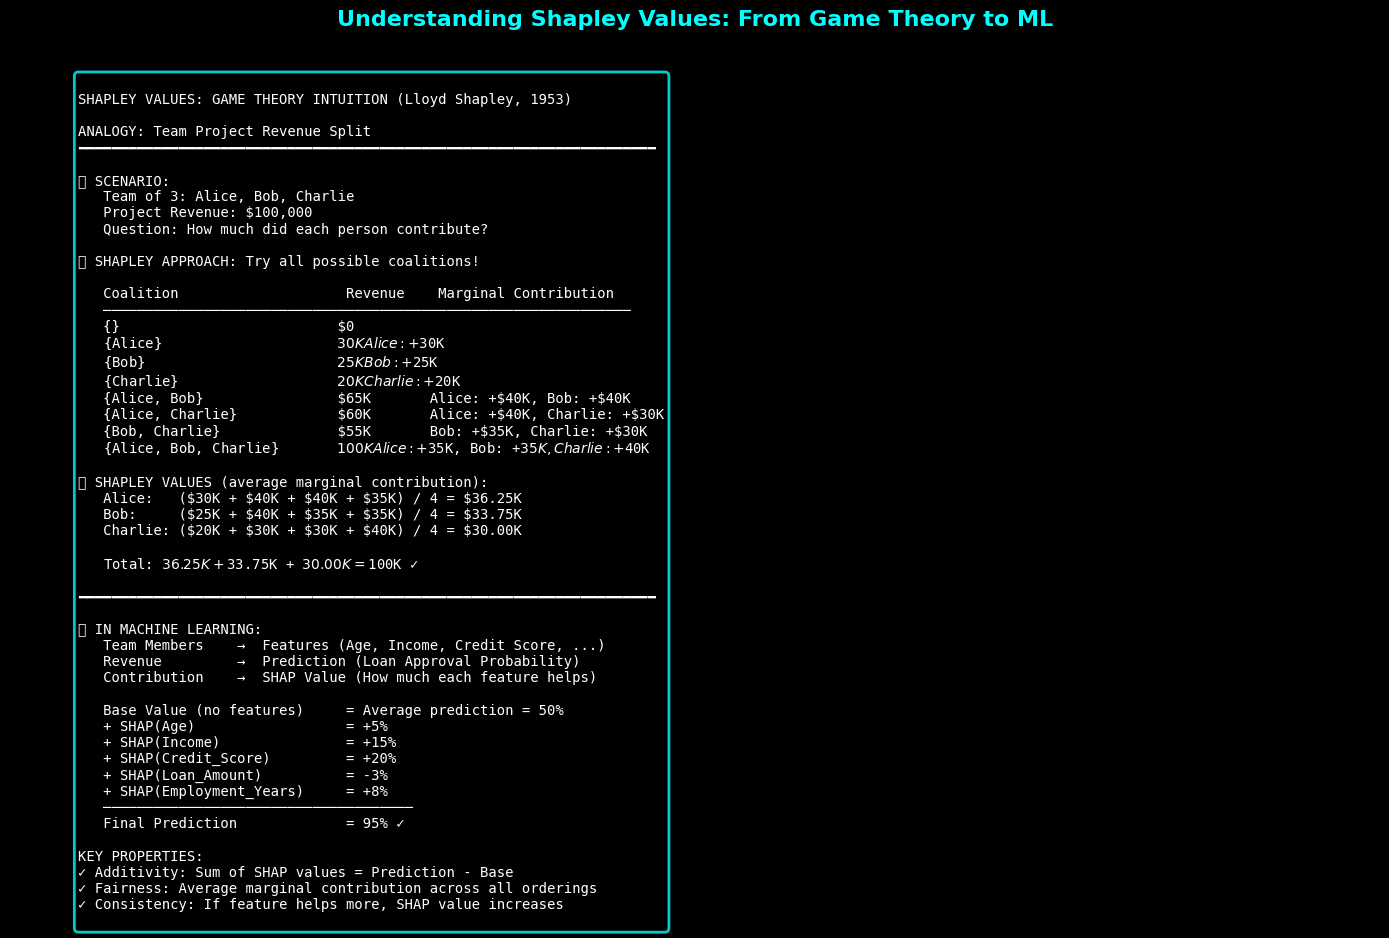


KEY INSIGHT:
SHAP values answer: 'How much does each feature contribute'
  by trying all possible feature combinations!

In practice: SHAP library optimizes this computation
  (brute force would be 2^n coalitions!)


In [23]:
# Visualize Shapley value concept
fig, ax = plt.subplots(figsize=(14, 8))

# Game theory analogy
text_content = """
SHAPLEY VALUES: GAME THEORY INTUITION (Lloyd Shapley, 1953)

ANALOGY: Team Project Revenue Split
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 SCENARIO:
   Team of 3: Alice, Bob, Charlie
   Project Revenue: $100,000
   Question: How much did each person contribute?

💡 SHAPLEY APPROACH: Try all possible coalitions!

   Coalition                    Revenue    Marginal Contribution
   ───────────────────────────────────────────────────────────────
   {}                          $0
   {Alice}                     $30K       Alice: +$30K
   {Bob}                       $25K       Bob: +$25K
   {Charlie}                   $20K       Charlie: +$20K
   {Alice, Bob}                $65K       Alice: +$40K, Bob: +$40K
   {Alice, Charlie}            $60K       Alice: +$40K, Charlie: +$30K
   {Bob, Charlie}              $55K       Bob: +$35K, Charlie: +$30K
   {Alice, Bob, Charlie}       $100K      Alice: +$35K, Bob: +$35K, Charlie: +$40K

📊 SHAPLEY VALUES (average marginal contribution):
   Alice:   ($30K + $40K + $40K + $35K) / 4 = $36.25K
   Bob:     ($25K + $40K + $35K + $35K) / 4 = $33.75K  
   Charlie: ($20K + $30K + $30K + $40K) / 4 = $30.00K
   
   Total: $36.25K + $33.75K + $30.00K = $100K ✓

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔄 IN MACHINE LEARNING:
   Team Members    →  Features (Age, Income, Credit Score, ...)
   Revenue         →  Prediction (Loan Approval Probability)
   Contribution    →  SHAP Value (How much each feature helps)

   Base Value (no features)     = Average prediction = 50%
   + SHAP(Age)                  = +5%
   + SHAP(Income)               = +15%
   + SHAP(Credit_Score)         = +20%
   + SHAP(Loan_Amount)          = -3%
   + SHAP(Employment_Years)     = +8%
   ─────────────────────────────────────
   Final Prediction             = 95% ✓

KEY PROPERTIES:
✓ Additivity: Sum of SHAP values = Prediction - Base
✓ Fairness: Average marginal contribution across all orderings
✓ Consistency: If feature helps more, SHAP value increases
"""

ax.text(0.05, 0.95, text_content, 
       transform=ax.transAxes, 
       fontsize=10, 
       verticalalignment='top',
       fontfamily='monospace',
       color='white',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='cyan', linewidth=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Understanding Shapley Values: From Game Theory to ML', 
            fontsize=16, fontweight='bold', color='cyan', pad=20)

plt.tight_layout()
plt.show()

print("\nKEY INSIGHT:")
print("="*70)
print("SHAP values answer: 'How much does each feature contribute'")
print("  by trying all possible feature combinations!")
print("\nIn practice: SHAP library optimizes this computation")
print("  (brute force would be 2^n coalitions!)")
print("="*70)

## 3. Computing SHAP Values

In [24]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Check the structure of shap_values
print("DEBUG: Type of shap_values:", type(shap_values))
print("DEBUG: X_test shape:", X_test.shape)

if isinstance(shap_values, list):
    print("DEBUG: shap_values is a list with length:", len(shap_values))
    print("DEBUG: Shape of shap_values[0]:", shap_values[0].shape)
    print("DEBUG: Shape of shap_values[1]:", shap_values[1].shape)
    # For binary classification, use class 1 (Approved)
    shap_values_approved = shap_values[1]
else:
    print("DEBUG: shap_values shape:", shap_values.shape)
    # Newer SHAP versions might return single array for binary classification
    shap_values_approved = shap_values

print("\nSHAP VALUES COMPUTED")
print("="*70)
print(f"Shape: {shap_values_approved.shape}")
print(f"  Expected: ({X_test.shape[0]} samples, {X_test.shape[1]} features)")

# Show SHAP values for our sample
sample_shap = shap_values_approved[sample_idx]
print(f"\nDEBUG: sample_shap shape: {sample_shap.shape}")
print(f"DEBUG: sample_shap type: {type(sample_shap)}")
print(f"DEBUG: First few values: {sample_shap[:3] if len(sample_shap.shape) == 1 else sample_shap}")

# If shape mismatch, try to fix it
if shap_values_approved.shape[0] != X_test.shape[0]:
    print("\n⚠️  WARNING: Shape mismatch detected!")
    print(f"   SHAP has {shap_values_approved.shape[0]} samples but X_test has {X_test.shape[0]} samples")
    print("   This might be due to API version differences. Recomputing...")
    
    # Try alternative computation
    shap_values_approved = explainer(X_test).values
    print(f"   New shape: {shap_values_approved.shape}")
    sample_shap = shap_values_approved[sample_idx]

# Get base value
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
else:
    base_value = explainer.expected_value

print(f"\nBase Value (Expected value): {base_value:.4f}")
print(f"\nFeature Contributions:")

# Ensure sample_shap is 1D
if len(sample_shap.shape) > 1:
    sample_shap = sample_shap.flatten()

for i, col in enumerate(X_test.columns):
    if i >= len(sample_shap):
        print(f"  ⚠️ Feature {col} has no SHAP value (index {i} out of bounds)")
        break
    value = sample.iloc[0][col]
    shap_val = sample_shap[i]
    arrow = "↑" if shap_val > 0 else "↓"
    color = "🟢" if shap_val > 0 else "🔴"
    print(f"  {col:20s} = {value:6.1f}  →  SHAP: {shap_val:+.4f} {arrow} {color}")

print(f"\n" + "-"*70)
print(f"Sum of SHAP values: {np.sum(sample_shap):.4f}")
print(f"\nFinal Prediction Calculation:")
print(f"  Base Value:        {base_value:.4f}")
print(f"  + Sum(SHAP):      {np.sum(sample_shap):+.4f}")
print(f"  {'─'*35}")
print(f"  = Prediction:      {base_value + np.sum(sample_shap):.4f}")

# Verify with model prediction
model_prob = rf.predict_proba(sample)[0][1]
print(f"\n  Model Probability: {model_prob:.4f}")
print(f"  Difference: {abs(model_prob - (base_value + np.sum(sample_shap))):.4f}")
if abs(model_prob - (base_value + np.sum(sample_shap))) < 0.01:
    print(f"  ✓ Match! SHAP values add up correctly!")
else:
    print(f"  ⚠️ Mismatch - may need to check SHAP computation")
print("="*70)

DEBUG: Type of shap_values: <class 'numpy.ndarray'>
DEBUG: X_test shape: (200, 5)
DEBUG: shap_values shape: (200, 5, 2)

SHAP VALUES COMPUTED
Shape: (200, 5, 2)
  Expected: (200 samples, 5 features)

DEBUG: sample_shap shape: (5, 2)
DEBUG: sample_shap type: <class 'numpy.ndarray'>
DEBUG: First few values: [[ 0.11361225 -0.11361225]
 [-0.32211491  0.32211491]
 [-0.04862075  0.04862075]
 [-0.01461746  0.01461746]
 [-0.00376032  0.00376032]]

Base Value (Expected value): 0.5050

Feature Contributions:
  Age                  =   22.0  →  SHAP: +0.1136 ↑ 🟢
  Income               =  139.0  →  SHAP: -0.1136 ↓ 🔴
  Credit_Score         =  589.0  →  SHAP: -0.3221 ↓ 🔴
  Loan_Amount          =   13.0  →  SHAP: +0.3221 ↑ 🟢
  Employment_Years     =   18.0  →  SHAP: -0.0486 ↓ 🔴

----------------------------------------------------------------------
Sum of SHAP values: -0.0000

Final Prediction Calculation:
  Base Value:        0.5050
  + Sum(SHAP):      -0.0000
  ───────────────────────────────────
 

## 4. Force Plot: Visualizing Single Prediction

In [25]:
# Create force plot
print("FORCE PLOT: Single Prediction Explanation")
print("="*70)
print("\nInterpretation:")
print("  • Base value (gray) = average prediction")
print("  • RED arrows = push toward REJECT (lower probability)")
print("  • BLUE arrows = push toward APPROVE (higher probability)")
print("  • Width of arrow = magnitude of effect")
print("  • Final prediction = where all arrows land")
print("="*70)

# Generate force plot
shap.force_plot(
    explainer.expected_value[1],
    shap_values_approved[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    figsize=(16, 4),
    show=True
)

plt.tight_layout()
plt.show()

FORCE PLOT: Single Prediction Explanation

Interpretation:
  • Base value (gray) = average prediction
  • RED arrows = push toward REJECT (lower probability)
  • BLUE arrows = push toward APPROVE (higher probability)
  • Width of arrow = magnitude of effect
  • Final prediction = where all arrows land


NotImplementedError: matplotlib = True is not yet supported for force plots with multiple samples!

## 5. Summary Plot: Global Feature Importance

In [ ]:
# Summary plot (bee swarm)
print("SUMMARY PLOT: Global Feature Importance")
print("="*70)
print("\nInterpretation:")
print("  • Y-axis: Features ranked by importance")
print("  • X-axis: SHAP value (impact on prediction)")
print("  • Each dot: One sample")
print("  • Color: Feature value (red=high, blue=low)")
print("  • Position: How much this feature pushed prediction")
print("\nWhat to look for:")
print("  • Wide spread = feature has varied impact")
print("  • Red dots on right = high feature value → higher prediction")
print("  • Blue dots on left = low feature value → lower prediction")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 8))
shap.summary_plot(
    shap_values_approved,
    X_test,
    show=False
)
plt.title('SHAP Summary Plot: Feature Impact on Loan Approval', 
         fontsize=16, fontweight='bold', color='cyan', pad=20)
plt.tight_layout()
plt.show()

# Mean absolute SHAP values (global importance)
mean_abs_shap = np.abs(shap_values_approved).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nFEATURE IMPORTANCE RANKING:")
print("="*70)
for idx, row in feature_importance.iterrows():
    bar = "█" * int(row['Mean |SHAP|'] * 50)
    print(f"{row['Feature']:20s} {bar} {row['Mean |SHAP|']:.4f}")
print("="*70)

## 6. Dependence Plot: Feature Effects

In [ ]:
# Dependence plots for top features
print("DEPENDENCE PLOTS: How Feature Values Affect Predictions")
print("="*70)
print("\nInterpretation:")
print("  • X-axis: Feature value")
print("  • Y-axis: SHAP value (impact on prediction)")
print("  • Color: Interaction with another feature")
print("  • Trend shows: How changing feature affects prediction")
print("="*70)

# Plot top 3 features
top_features = feature_importance['Feature'].head(3).values

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    shap.dependence_plot(
        feature,
        shap_values_approved,
        X_test,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence: {feature}', 
                fontsize=14, fontweight='bold', color='cyan', pad=15)

plt.suptitle('SHAP Dependence Plots: Feature Effects', 
            fontsize=16, fontweight='bold', color='yellow', y=1.02)
plt.tight_layout()
plt.show()

print("\nOBSERVATIONS:")
print("  → Higher Credit Score = Strong positive impact")
print("  → Higher Income = Positive impact")
print("  → Relationships may be non-linear!")
print("  → Colors show interaction effects with other features")

## 7. Complete Example: Multiple Predictions

In [ ]:
# Show 3 different cases
cases = [
    {'name': 'STRONG APPROVAL', 'idx': np.where((y_test == 1) & (rf.predict_proba(X_test)[:, 1] > 0.9))[0][0]},
    {'name': 'BORDERLINE', 'idx': np.where(np.abs(rf.predict_proba(X_test)[:, 1] - 0.5) < 0.05)[0][0]},
    {'name': 'STRONG REJECTION', 'idx': np.where((y_test == 0) & (rf.predict_proba(X_test)[:, 1] < 0.1))[0][0]}
]

print("COMPARING 3 DIFFERENT CASES")
print("="*70)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for idx, case in enumerate(cases):
    case_idx = case['idx']
    case_name = case['name']
    
    sample_case = X_test.iloc[case_idx]
    pred = rf.predict_proba(X_test.iloc[case_idx:case_idx+1])[0][1]
    
    print(f"\nCase {idx+1}: {case_name}")
    print("-"*70)
    print(f"Prediction: {pred:.1%} approval probability")
    print(f"Features: Age={sample_case['Age']}, Income={sample_case['Income']}K, "
          f"Credit={sample_case['Credit_Score']}, Loan={sample_case['Loan_Amount']}K")
    
    # Create horizontal bar chart of SHAP values
    ax = axes[idx]
    shap_vals = shap_values_approved[case_idx]
    
    # Sort by absolute value
    sort_idx = np.argsort(np.abs(shap_vals))[::-1]
    
    colors = ['lime' if v > 0 else 'red' for v in shap_vals[sort_idx]]
    
    ax.barh(range(len(sort_idx)), shap_vals[sort_idx], color=colors, alpha=0.7, edgecolor='white', linewidth=2)
    ax.set_yticks(range(len(sort_idx)))
    ax.set_yticklabels([X_test.columns[i] for i in sort_idx], fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP Value (Impact on Prediction)', fontsize=12, fontweight='bold')
    ax.axvline(0, color='white', linestyle='--', linewidth=2, alpha=0.5)
    ax.grid(alpha=0.3, axis='x')
    
    # Add base value line
    base = explainer.expected_value[1]
    final = base + np.sum(shap_vals)
    
    title_color = 'lime' if pred > 0.7 else 'red' if pred < 0.3 else 'yellow'
    ax.set_title(f"Case {idx+1}: {case_name} | Prediction: {pred:.1%} | Base: {base:.2f} → Final: {final:.2f}",
                fontsize=13, fontweight='bold', color=title_color, pad=15)
    
    # Add legend
    ax.text(0.98, 0.95, 'Green = Pushes Approval\nRed = Pushes Rejection',
           transform=ax.transAxes, ha='right', va='top',
           fontsize=10, bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.suptitle('SHAP Analysis: 3 Different Loan Applications', 
            fontsize=16, fontweight='bold', color='cyan', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("  • Strong Approval: Credit Score dominates (large positive SHAP)")
print("  • Borderline: Mixed signals - some features push up, some down")
print("  • Strong Rejection: Low credit score is main negative driver")
print("="*70)

## 8. Key Takeaways

### What is SHAP?

**Definition:**
- SHAP = SHapley Additive exPlanations
- Method to explain predictions of ANY machine learning model
- Based on Shapley values from cooperative game theory (1953)

**Core Concept:**
```
Prediction = Base Value + Σ(SHAP values)
```

### The Three Components:

**1. Base Value (E[f(x)]):**
- Average model prediction across training data
- What we'd predict if we knew NOTHING about the sample
- Starting point for explanation

**2. SHAP Values (φᵢ):**
- Contribution of each feature to the prediction
- Positive = pushes prediction UP
- Negative = pushes prediction DOWN
- Magnitude = strength of effect

**3. Final Prediction:**
- Base + sum of all SHAP values
- SHAP values ALWAYS add up exactly!

### Mathematical Foundation:

**Shapley Value Formula:**
```
φᵢ = Σ [|S|! × (|N| - |S| - 1)! / |N|!] × [f(S ∪ {i}) - f(S)]
     S⊆N\{i}
```

Where:
- φᵢ = SHAP value for feature i
- S = subset of features (coalition)
- N = all features
- f(S) = model prediction with features in S

**Properties:**
- ✓ **Additivity**: SHAP values sum to (prediction - base)
- ✓ **Local accuracy**: f(x) = E[f(x)] + Σφᵢ
- ✓ **Consistency**: If feature helps more, SHAP increases
- ✓ **Missingness**: Missing feature has SHAP = 0

### Types of SHAP Explainers:

**1. TreeExplainer:**
- For tree-based models (RF, XGBoost, LightGBM)
- Very fast (polynomial time)
- Exact SHAP values
```python
explainer = shap.TreeExplainer(model)
```

**2. DeepExplainer:**
- For neural networks
- Approximation using DeepLIFT
```python
explainer = shap.DeepExplainer(model, background_data)
```

**3. KernelExplainer:**
- Model-agnostic (works with ANY model)
- Slower (sampling-based)
```python
explainer = shap.KernelExplainer(model.predict, background_data)
```

### Visualization Types:

**1. Force Plot:**
- Single prediction explanation
- Shows how each feature pushes from base
- Red = negative impact, Blue = positive impact
```python
shap.force_plot(base_value, shap_values[i], X.iloc[i])
```

**2. Summary Plot (Bee Swarm):**
- Global feature importance
- Each dot = one sample
- Color = feature value (red=high, blue=low)
- Position = SHAP value impact
```python
shap.summary_plot(shap_values, X)
```

**3. Dependence Plot:**
- Relationship between feature value and SHAP value
- Shows non-linear effects
- Color = interaction with another feature
```python
shap.dependence_plot('feature_name', shap_values, X)
```

**4. Waterfall Plot:**
- Shows cumulative feature contributions
- From base value to final prediction
```python
shap.waterfall_plot(shap_values[i])
```

### When to Use SHAP:

**✓ Use SHAP when:**
- Need to explain complex black-box models
- Regulatory requirements (finance, healthcare)
- Debugging model behavior
- Building trust with stakeholders
- Finding feature interactions
- Model comparison and selection

**Advantages:**
- ✓ Model-agnostic (works with any model)
- ✓ Theoretically sound (game theory foundation)
- ✓ Consistent and fair
- ✓ Local AND global explanations
- ✓ Additive (values sum exactly)

**Disadvantages:**
- ✗ Computationally expensive (except TreeExplainer)
- ✗ Requires background data for some explainers
- ✗ Can be slow for large datasets
- ✗ Interpretation requires understanding

### Common Use Cases:

**1. Finance:**
- Loan approval explanations
- Credit scoring transparency
- Fraud detection reasoning

**2. Healthcare:**
- Diagnosis explanations
- Treatment recommendations
- Risk factor identification

**3. Fairness & Bias:**
- Detecting biased features
- Ensuring fair treatment
- Compliance with regulations

**4. Model Debugging:**
- Finding data leakage
- Identifying spurious correlations
- Validating feature engineering

### Installation & Usage:

```bash
pip install shap
```

```python
import shap

# Train model
model.fit(X_train, y_train)

# Create explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Visualize
shap.summary_plot(shap_values, X_test)
```

### Alternatives to SHAP:

**LIME (Local Interpretable Model-agnostic Explanations):**
- Fits local linear model around prediction
- Faster but less consistent
- Good for quick explanations

**Feature Importance:**
- Built-in to tree models
- Global only (no local explanations)
- Very fast

**Permutation Importance:**
- Shuffle feature and measure impact
- Model-agnostic
- Global importance only

### Best Practices:

**1. Use appropriate explainer:**
- TreeExplainer for tree models (fastest)
- DeepExplainer for neural nets
- KernelExplainer as fallback

**2. Sample for large datasets:**
```python
# Use subset for faster computation
shap_values = explainer.shap_values(X_test.sample(1000))
```

**3. Check additivity:**
```python
# Verify SHAP values add up
assert np.allclose(
    base_value + shap_values.sum(),
    model.predict(X)
)
```

**4. Combine visualizations:**
- Summary plot for overview
- Force plot for individual cases
- Dependence plot for relationships

### Remember:
- **SHAP values explain HOW features contribute**
- **Base value = starting point (average prediction)**
- **Positive SHAP = pushes UP, Negative = pushes DOWN**
- **Sum of SHAP = Prediction - Base (exactly!)**
- **Works with ANY model** (trees, neural nets, etc.)
- **Game theory foundation** = fair and consistent
- **Essential for explainable AI** and regulatory compliance! 🎯